In [17]:
import numpy as np
from scipy.interpolate import CubicSpline
import json 

In [18]:
import matplotlib.pyplot as plt
from matplotlib import rc
from typing import Dict, Tuple, Literal, List
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os

os.environ['PATH'] = f"/Library/TeX/texbin:{os.environ['PATH']}"
rc('text', usetex=True)
plt.rcParams['text.usetex'] = True
rc('font', **{'family': 'serif'})
plt.rcParams.update({'font.size': 20})

In [19]:
# Fit results for different truncations
fit_results = {eft_truncation: {mxx: [] for mxx in range(4, 11)} for eft_truncation in ["d6", "d6sq"]}

for eft_truncation in fit_results:
    with open(f"../../FitStats/Zprime/{eft_truncation}/C2JB.json") as file_:
        fit_info = json.load(file_)
    
    for benchmark in fit_info:
        fit_results[eft_truncation][benchmark["MXX"]].append(
            {
                "beta": benchmark["beta"], 
                "MinChiSq": benchmark["MinChiSquare"],
                "ChiSq-SM": benchmark["ChiSq-SM"]
            }
        ) 
    
    # Sort by beta
    for mxx, min_chi_sq in fit_results[eft_truncation].items():
        fit_results[eft_truncation][mxx] = sorted(min_chi_sq, key=lambda entry: entry["beta"])

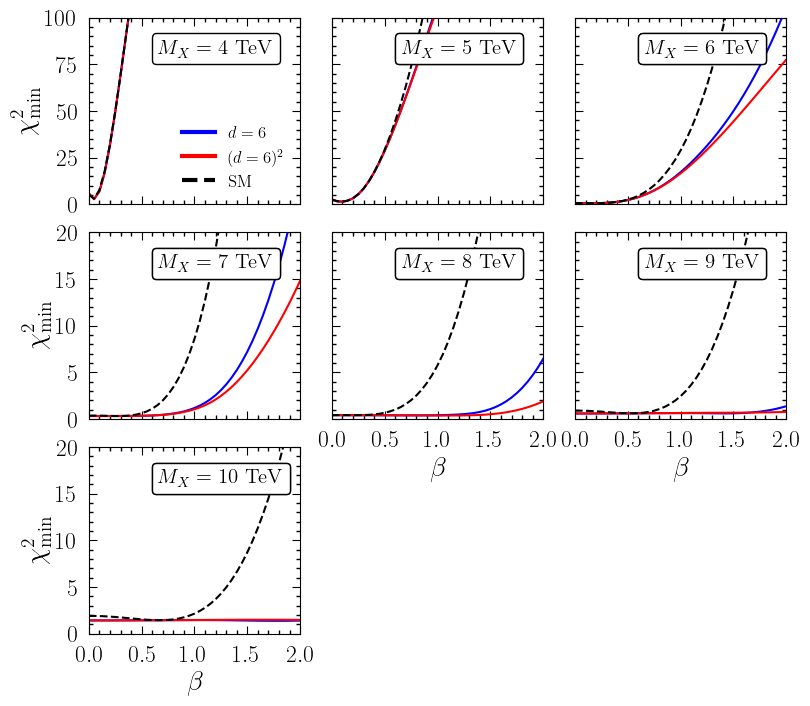

In [68]:
fig, ax = plt.subplots(3, 3, figsize=(9, 8))
# spacing
plt.subplots_adjust(wspace=0.15, hspace=0.15)
plt.gca().set_aspect('equal')
ax[2, 1].axis("off")
ax[2, 2].axis("off")

colors = {
    "d6": "blue",
    "d6sq": "red",
    "SM": "black"
}

plot_legs = [
    Line2D([0], [0], linestyle="solid", color=colors["d6"], alpha=1, label=r"$d=6$", lw=3),
    Line2D([0], [0], linestyle="solid", color=colors["d6sq"], alpha=1, label=r"$(d=6)^2$", lw=3),
    Line2D([0], [0], linestyle="dashed", color=colors["SM"], alpha=1, label=r"SM", lw=3),
]

index_row, index_col = 0, 0

x_axis = np.arange(0, 2.2, 0.05)

# Loop over the masses
for mxx in range(4, 11):    
    # Interpolate the results for different truncations 
    for eft in ["d6", "d6sq"]:
        beta_values = np.array([entry["beta"] for entry in fit_results[eft][mxx]])
        chisq_min = np.array([entry["MinChiSq"] for entry in fit_results[eft][mxx]])
        # Interpolation
        interp_chisq = CubicSpline(beta_values, chisq_min)
    
        # plot results
        ax[index_row, index_col].plot(x_axis, interp_chisq(x_axis), color=colors[eft])
    
    # Interpolates SM
    chisq_min = np.array([entry["ChiSq-SM"] for entry in fit_results[eft][mxx]])
    # Interpolation
    interp_chisq = CubicSpline(beta_values, chisq_min)
    # plot results
    ax[index_row, index_col].plot(x_axis, interp_chisq(x_axis), color=colors["SM"], linestyle="dashed")
    
    xlim = (0, 100) if index_row == 0 else (0, 20)
        
    ax[index_row, index_col].set_ylim(xlim)
    ax[index_row, index_col].set_xlim((0, 2))
    
    # Ticks
    ax[index_row, index_col].xaxis.set_minor_locator(AutoMinorLocator())
    ax[index_row, index_col].yaxis.set_minor_locator(AutoMinorLocator())
    ax[index_row, index_col].tick_params(axis="both", which="minor", top=True, right=True, length=3, direction="in", width=1)
    ax[index_row, index_col].tick_params(axis="both", which="major", top=True, right=True, length=6, direction="in", labelsize=17, pad=8)
    
    # adjusting the limits of the plots
    ax[index_row, index_col].set_xticks(np.linspace(0, 2, 5))
    ax[index_row, index_col].set_yticks(np.linspace(*xlim, 5))
    
    if index_row == 0 or (index_row == 1 and index_col == 0):
        ax[index_row, index_col].tick_params(axis="x", labelbottom=False)
    else:
        ax[index_row, index_col].set_xlabel(r"$\beta$")

    leg_mxx = [Line2D([], [], linestyle='None', markersize=0, label=fr"$M_{{X}} = {mxx}$ TeV")]
    mxx_label = ax[index_row, index_col].legend(handles=leg_mxx, fancybox=True, frameon=True, framealpha=1, edgecolor="black", ncols=1, fontsize=15, loc=(0.3, 0.75), borderpad=0.3,  handlelength=0, handletextpad=0)
    ax[index_row, index_col].add_artist(mxx_label)
    if index_col > 0:
        ax[index_row, index_col].tick_params(axis="y", labelleft=False)
    else:
        ax[index_row, index_col].set_ylabel(r"$\chi^2_\mathrm{min}$")
        
    index_col += 1
    if index_col == 3:
        index_row += 1
        index_col = 0

ax[0, 0].legend(handles=plot_legs, fancybox=True, frameon=False, framealpha=0.7, edgecolor="black", ncols=1, fontsize=12, loc="lower right", borderpad=0.4)
plt.savefig(f"../../Plots/MinChiSq-Zp.pdf", format="pdf", bbox_inches="tight", dpi=300)